In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('50_Startups.csv')

print(df.head())


   R&D Spend  Administration  Marketing Spend       State     Profit
0  165349.20       136897.80        471784.10    New York  192261.83
1  162597.70       151377.59        443898.53  California  191792.06
2  153441.51       101145.55        407934.54     Florida  191050.39
3  144372.41       118671.85        383199.62    New York  182901.99
4  142107.34        91391.77        366168.42     Florida  166187.94


In [47]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

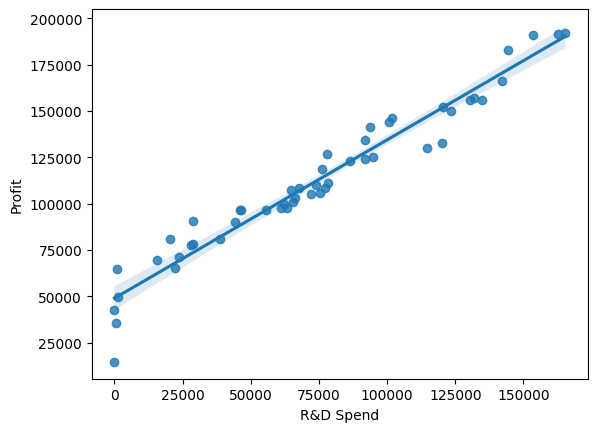

In [48]:
sns.regplot(x=df['R&D Spend'], y=df['Profit'])
plt.show()

In [49]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
data=make_column_transformer((OneHotEncoder(handle_unknown='ignore'),['State']),remainder='passthrough')
x=data.fit_transform(x)

In [50]:
x.shape

(50, 6)

In [51]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [52]:
from sklearn.linear_model import LinearRegression
linear=LinearRegression()
linear.fit(x_train,y_train)

LinearRegression()

In [53]:
y_pred=linear.predict(x_test)
y_pred

array([126187.39411505,  85788.82259514,  99777.02815178,  45706.1223833 ,
       127062.20722771,  51891.8388446 , 109114.62977495, 100600.61123703,
        97953.99874718, 111730.57706811, 128818.49200667, 174195.3577263 ,
        93736.2853844 , 148381.04097159, 172313.87139388])

In [54]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_absolute_percentage_error,mean_squared_error
print('R2 Score',r2_score(y_test,y_pred)*100)
print('Mean Absolute Error',mean_absolute_error(y_test,y_pred))
print('mean_absolute_percentage_error',mean_absolute_percentage_error(y_test,y_pred))
print('mean_squared_error',mean_squared_error(y_test,y_pred))

R2 Score 93.97108063355876
Mean Absolute Error 7395.433531524327
mean_absolute_percentage_error 0.08929865344176709
mean_squared_error 84826955.03532155


In [55]:
df2=pd.DataFrame({'Actual_value':y_test,'Predicted_value':y_pred,'Difference':y_pred-y_test})
df2

,Actual_value,Predicted_value,Difference
13,134307.35,126187.394115,-8119.955885
39,81005.76,85788.822595,4783.062595
30,99937.59,99777.028152,-160.561848
45,64926.08,45706.122383,-19219.957617
17,125370.37,127062.207228,1691.837228
48,35673.41,51891.838845,16218.428845
26,105733.54,109114.629775,3381.089775
25,107404.34,100600.611237,-6803.728763
32,97427.84,97953.998747,526.158747
19,122776.86,111730.577068,-11046.282932
